C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\2721285585.py:14: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('01_kaggle_rossmann/rossmann_store_sales_train.csv')




1. Data Exploration



__________Exploring test_dataset__________
Id                             int64
Store                          int64
DayOfWeek                      int64
Date                             str
Open                         float64
Promo                          int64
StateHoliday                     str
SchoolHoliday                  int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object

__________Exploring train_dataset__________
Store                          int64
DayOfWeek                      int64
Date                             str
Sales                          int64
Customers                      int64
Open                           int64
Promo                 

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\2721285585.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1            = sns.barplot(data=avg_daily_sort, x='StoreType', y='Sales', palette=palette_stores, edgecolor='white', linewidth=1.2)


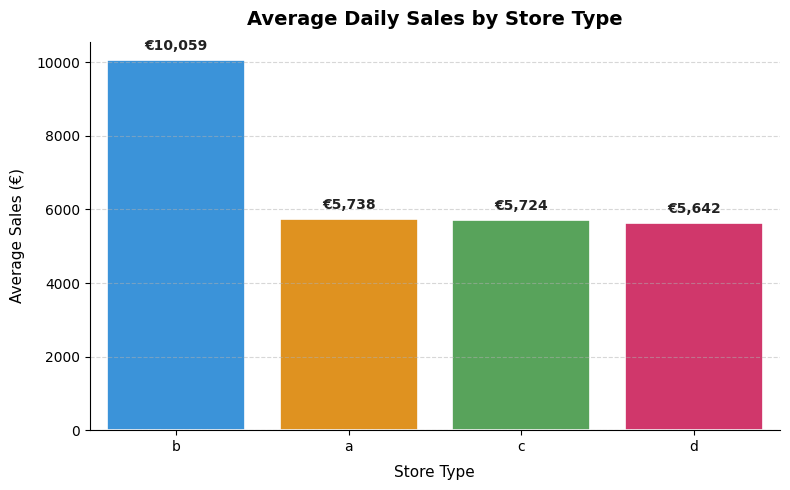

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\2721285585.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2           = sns.barplot(data=sale_after_promo, x='Promo', y='Sales', palette=palette_promo, edgecolor='white', linewidth=1.2)
C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\2721285585.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['No Promotion', 'With Promotion'], fontsize=11)


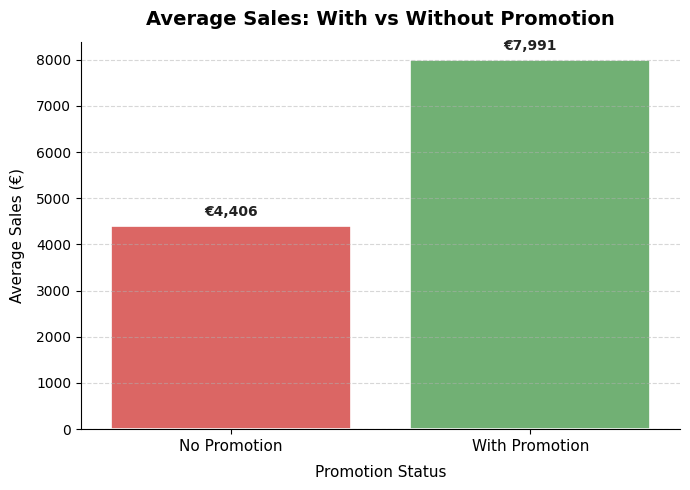

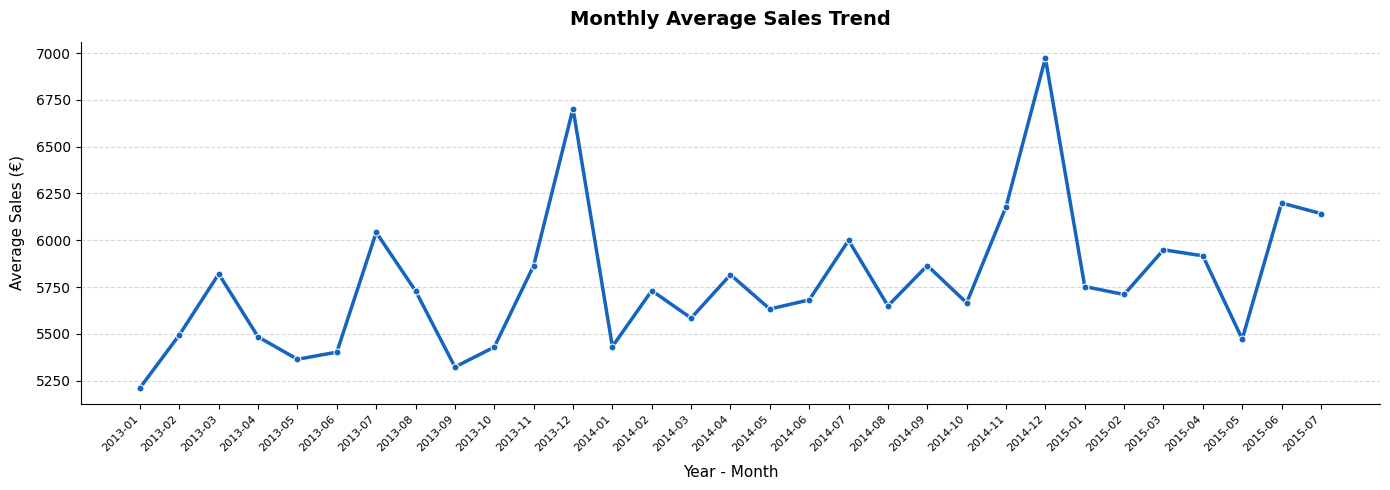

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\2721285585.py:202: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_hol_plot, x='Label', y='Sales', palette=palette_state, edgecolor='white', linewidth=1.2, ax=ax4a)
C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\2721285585.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=school_hol_plot, x='Label', y='Sales', palette=palette_school, edgecolor='white', linewidth=1.2, ax=ax4b)


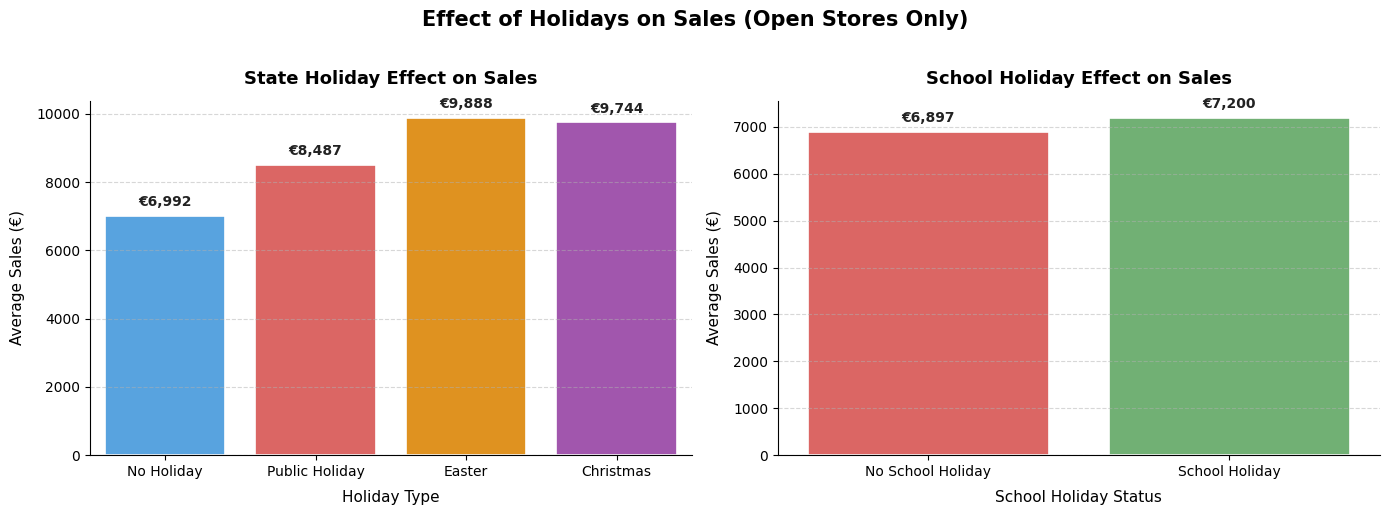

In [2]:
"""
Project on  : Retail pricing and demand forecasting 
prepared by : Ali Akbar
Date        : 02/05/2026
"""
# ================= Kaggle rossmann dataset (sale_dataset) =================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

meta  = pd.read_csv('01_kaggle_rossmann/rossmann_store_metadata.csv')
test  = pd.read_csv('01_kaggle_rossmann/rossmann_store_sales_test.csv')
train = pd.read_csv('01_kaggle_rossmann/rossmann_store_sales_train.csv')

test_merged  = test.merge(meta, on='Store', how='left')
train_merged = train.merge(meta, on='Store', how='left')

df_test  = pd.DataFrame(test_merged)
df_train = pd.DataFrame(train_merged)

data_information_test  = df_test.dtypes
data_information_train = df_train.dtypes

print("\n"+'='*70)
print("\n"+'1. Data Exploration')
print("\n"+'='*70)

print("\n"+"="*70)

print("\n"+"_"*10+'Exploring test_dataset'+'_'*10)
print(data_information_test)
print("\n"+"_"*10+'Exploring train_dataset'+'_'*10)
print(data_information_train)
data1_info_te          = df_test.info()
data2_info_tr          = df_train.info()
df_test.describe()
df_train.describe()

print("\n"+"="*70)

# Finding and handling missing values 

# =========================================================================
# These are the columns we gonaa focus on for getting the preffered answers
# [Store, Date, Sales, Customers, Open, promo, StateHoliday, StoreType, Assortment, CompetitionDistance]
# =========================================================================
df_train['CompetitionOpenSinceMonth'] = df_train['CompetitionOpenSinceMonth'].fillna(df_train['CompetitionOpenSinceMonth'].value_counts().idxmax())
df_train['CompetitionOpenSinceMonth'].isnull().sum()

df_train['CompetitionDistance']       = df_train['CompetitionDistance'].fillna(df_train['CompetitionDistance'].mean())
df_train['CompetitionDistance'].isnull().sum()

# Other Columns like Date, Store, Sales, Promo, StateHoliday,StoreType ... have 0 missing values

# ========================================================================

# Finding answers of question through analysis
# ________________________________________________________________________
# Qno1. Which store type generates the highest average daily sales?
daily_sale     = df_train.groupby(['StoreType', 'Date'])['Sales'].mean().reset_index()
daily_sale

avg_daily_sale = df_train.groupby('StoreType')['Sales'].mean().reset_index()
avg_daily_sale

avg_daily_sort = avg_daily_sale.sort_values('Sales', ascending=False)

# ________________________________________________________________________
# Qno2. Does running a promotion increase sales, and by how much?
sale_after_promo = df_train.groupby('Promo')['Sales'].mean().reset_index() # grouping promotion and sales data 

with_promo       = sale_after_promo.loc[sale_after_promo['Promo'] == 1]    # seperating columns with promotion
without_promo    = sale_after_promo.loc[sale_after_promo['Promo'] == 0]    # seperating columns without promotion 

with_sale        = with_promo['Sales'].values[0]
without_sale     = without_promo['Sales'].values[0]

left             = with_sale - without_sale
pct_left         = (left/without_sale) * 100


# ________________________________________________________________________
# Qno3. What is the monthly sales trend? Is there a seasonal pattern?
df_train['Date']      = pd.to_datetime(df_train['Date'])                    # Converting Date column form str to datetime
df_train['YearMonth'] = df_train['Date'].dt.to_period('M')                  # Extracting month and year from the date columns
avg_sale_perM         = df_train.groupby('YearMonth')['Sales'].mean().reset_index()

# ________________________________________________________________________
# Qno4. Do Holidays hurt or boost the sales
df_open           = df_train[df_train['Open'] == 1]                         # filter: exclude closed stores (Sales=0 on closure days skews holiday averages)
state_hol_effect  = df_open.groupby('StateHoliday')['Sales'].mean().reset_index()
school_hol_effect = df_open.groupby('SchoolHoliday')['Sales'].mean().reset_index()

# _________________Code for Printing results______________________________
print("\n"+'='*70) #starting line
# Question no 3

print("\n"+'_'*10+"Analyzing data for getting insights"+'_'*10) # starting border
print("\n"+"Q#1. Which store type generates the highest average daily sales?") # Question no 1
print("\n"+ "daily_sales")
print("\n", daily_sale)
print("\n"+ "Average Daily Sales")
print("\n", avg_daily_sale)
print("\n"+"Sorted Average Sales")
print("\n", avg_daily_sort)
# Question no 2
print("\n"+'_'*70)
print("\n"+" Q#2.  Does running a promotion increase sales, and by how much?") # Question no 2
print("\n"+" average of Sales after promotion")
print("\n", sale_after_promo)
print("\n"+"Sales With Promotion =")
print("\n",with_promo)
print("\n"+"Sales before Promotion =")
print("\n",without_promo)
print("\n"+"Different between sales with promotion and withot =", left)
print("\n"+"Different perfectage =", pct_left,"%") 
# Question no 3
print("\n"+'_'*70)
print("\n"+ 'Q#3.  What is the monthly sales trend? Is there a seasonal pattern?')
print("\n"+ "Average sales per month")
print("\n", avg_sale_perM)

print("\n"+"_"*70)
print("\n"+"Q#4. Do Holiday hurt or boost the sales")
print("\n"+" State Holiday effect on sales")
print("\n", state_hol_effect)
print("\n"+" School Holiday effect on sales")
print("\n", school_hol_effect)

# _________________Conclustion section _______________________________
print("\n"+'='*70)
print("\n"+'Conslusione'+'_'*10) # Conclusione
print("\n"+"Answer of Question # 1")
print(" According to the data and the Charts which is driven by Rossmann dataset Store B is generating more sales respect to Store A, Store C, Store D")
print("\n"+"Answer of question # 2")
print(f"According to the data and the charts We can see a huge uptrend in sales after promotion about 81% of increase in sales after promotion  ")

print("\n"+'='*70) # Ending line

# ________________ Ploting all the importany data_____________________

# Chart 1 — Average Daily Sales by Store Type
plt.figure(figsize=(8, 5))
palette_stores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
ax1            = sns.barplot(data=avg_daily_sort, x='StoreType', y='Sales', palette=palette_stores, edgecolor='white', linewidth=1.2)
for p in ax1.patches:
    ax1.annotate(f'€{p.get_height():,.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222',
                 xytext=(0, 5), textcoords='offset points')
plt.title('Average Daily Sales by Store Type', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Store Type',         fontsize=11, labelpad=8)
plt.ylabel('Average Sales (€)',  fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 2 — Average Sales: With vs Without Promotion
plt.figure(figsize=(7, 5))
palette_promo = ['#EF5350', '#66BB6A']
ax2           = sns.barplot(data=sale_after_promo, x='Promo', y='Sales', palette=palette_promo, edgecolor='white', linewidth=1.2)
ax2.set_xticklabels(['No Promotion', 'With Promotion'], fontsize=11)
for p in ax2.patches:
    ax2.annotate(f'€{p.get_height():,.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222',
                 xytext=(0, 5), textcoords='offset points')
plt.title('Average Sales: With vs Without Promotion', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Promotion Status',  fontsize=11, labelpad=8)
plt.ylabel('Average Sales (€)', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 3 — Monthly Average Sales Trend
avg_sale_plot              = avg_sale_perM.copy()
avg_sale_plot['YearMonth'] = avg_sale_plot['YearMonth'].astype(str)        # convert Period to str for seaborn
plt.figure(figsize=(14, 5))
ax3 = sns.lineplot(data=avg_sale_plot, x='YearMonth', y='Sales', color='#1565C0', linewidth=2.5, marker='o', markersize=5)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Monthly Average Sales Trend', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Year - Month',      fontsize=11, labelpad=8)
plt.ylabel('Average Sales (€)', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 4 — Holiday effect on sales (two side-by-side barplots)
state_hol_plot          = state_hol_effect.copy()
state_hol_plot['Label'] = state_hol_plot['StateHoliday'].map({'0': 'No Holiday', 'a': 'Public Holiday', 'b': 'Easter', 'c': 'Christmas'})

school_hol_plot          = school_hol_effect.copy()
school_hol_plot['Label'] = school_hol_plot['SchoolHoliday'].map({0: 'No School Holiday', 1: 'School Holiday'})

fig, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(14, 5))

palette_state = ['#42A5F5', '#EF5350', '#FF9800', '#AB47BC']
sns.barplot(data=state_hol_plot, x='Label', y='Sales', palette=palette_state, edgecolor='white', linewidth=1.2, ax=ax4a)
for p in ax4a.patches:
    ax4a.annotate(f'€{p.get_height():,.0f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222',
                  xytext=(0, 5), textcoords='offset points')
ax4a.set_title('State Holiday Effect on Sales',  fontsize=13, fontweight='bold', pad=12)
ax4a.set_xlabel('Holiday Type',       fontsize=11, labelpad=8)
ax4a.set_ylabel('Average Sales (€)',  fontsize=11, labelpad=8)
ax4a.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax4a)

palette_school = ['#EF5350', '#66BB6A']
sns.barplot(data=school_hol_plot, x='Label', y='Sales', palette=palette_school, edgecolor='white', linewidth=1.2, ax=ax4b)
for p in ax4b.patches:
    ax4b.annotate(f'€{p.get_height():,.0f}',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222',
                  xytext=(0, 5), textcoords='offset points')
ax4b.set_title('School Holiday Effect on Sales', fontsize=13, fontweight='bold', pad=12)
ax4b.set_xlabel('School Holiday Status', fontsize=11, labelpad=8)
ax4b.set_ylabel('Average Sales (€)',     fontsize=11, labelpad=8)
ax4b.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax4b)

plt.suptitle('Effect of Holidays on Sales (Open Stores Only)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [3]:
df_train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,YearMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015-07
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015-07
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015-07
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015-07
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015-07




1. Data Exploration


__________Exploring train_dataset__________
date       str
store    int64
item     int64
sales    int64
dtype: object

______________________________________________________________________

__________Retailed data info__________
Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\1549156885.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1         = sns.barplot(data=avg_units_cat, x='Category', y='Units Sold', palette=palette_cat, edgecolor='white', linewidth=1.2)


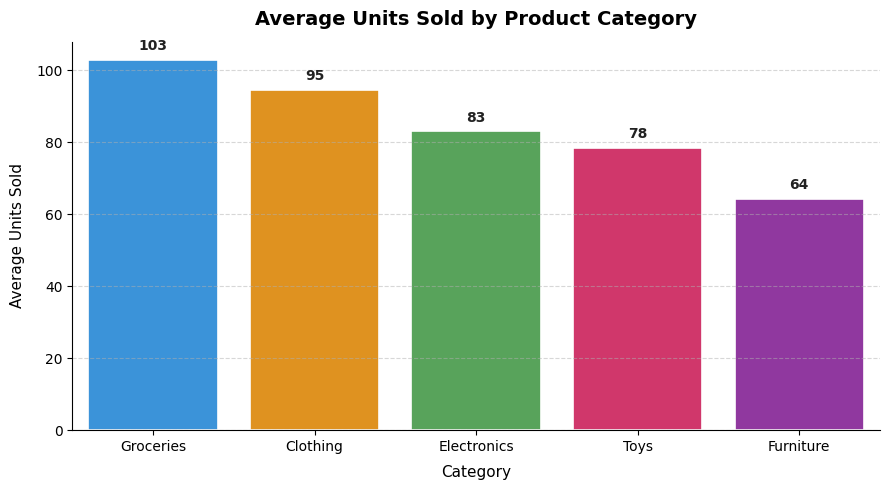

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\1549156885.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2           = sns.barplot(data=avg_price_cat, x='Category', y='Price', palette=palette_price, edgecolor='white', linewidth=1.2)


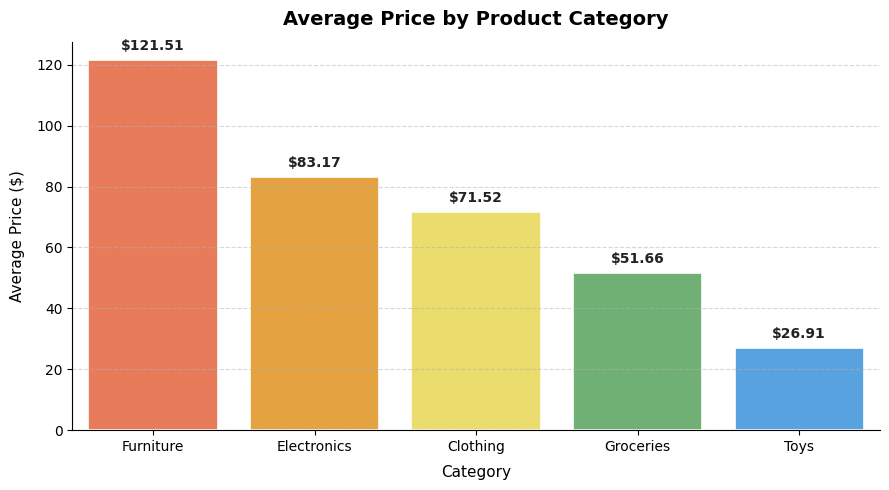

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\1549156885.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=avg_demand_season, x='Seasonality', y='Demand', order=season_order, palette=palette_season, edgecolor='white', linewidth=1.2)


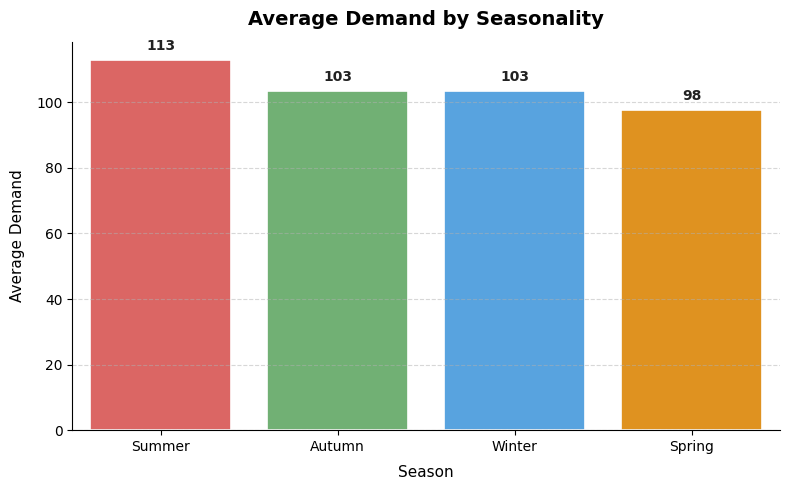

In [4]:
# ================= Kaggle Demand forcasting dataset (inventory_dataset) =================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Extracting retail inventory sales data _________________
sale_data  = pd.read_csv("02_kaggle_demand_forecasting/retail_inventory_sales.csv")
sale_test  = pd.read_csv("02_kaggle_demand_forecasting/store_item_demand_test.csv")
sale_train = pd.read_csv("02_kaggle_demand_forecasting/store_item_demand_train.csv")

df_sale_train = pd.DataFrame(sale_train)
df_sales       = pd.DataFrame(sale_data)

df_sale_infotrain = df_sale_train.dtypes
df_sale_info      = df_sales.dtypes

df_sales = df_sales.rename(columns={
    'Store Id'   : 'StoreId',
    'Product Id' : 'ProductId'
})

# All the code for printing 

print("\n"+'='*70)
print("\n"+'1. Data Exploration')
print("\n"+'='*70)

print("\n"+"_"*10+'Exploring train_dataset'+'_'*10)
print(df_sale_infotrain)
print("\n"+'_'*70)
print("\n"+'_'*10+'Retailed data info'+'_'*10)
print(df_sale_info)
data2_info_tr          = df_sale_train.info()

print("\n"+'_'*10+'Description of dataset'+'_'*10)
df_sales.describe()
df_sale_train.describe

print("\n"+"="*70)

# Finding and handling all the missing values

# =========================================================================
# These are the columns we gonaa focus on for getting the preffered answers
# [sale_data, Date, Category, Price, Discount, Units Sold, Promotion, Competitor Pricing, Seasonality, Demand]
# =========================================================================

df_sales['Seasonality'].isnull().sum() 

# Every columns in this dataset had 0 missing value

# ________________________________________________________________________
# Finding answers of question through analysis
# ________________________________________________________________________
# Qno1. Which product category sells the most units on average?
avg_units_cat  = df_sales.groupby('Category')['Units Sold'].mean().reset_index()
avg_units_cat  = avg_units_cat.sort_values('Units Sold', ascending=False)

# ________________________________________________________________________
# Qno2. Which product category has the highest average price?
avg_price_cat  = df_sales.groupby('Category')['Price'].mean().reset_index()
avg_price_cat  = avg_price_cat.sort_values('Price', ascending=False)

# ________________________________________________________________________
# Qno3. How does seasonality affect average demand?
avg_demand_season = df_sales.groupby('Seasonality')['Demand'].mean().reset_index()
avg_demand_season = avg_demand_season.sort_values('Demand', ascending=False)

# _________________Code for Printing results______________________________
print("\n"+'='*70)
print("\n"+"_"*70)
print("\n"+"Q#1. Which product category sells the most units on average?")
print("\n", avg_units_cat)
print("\n"+"_"*70)
print("\n"+"Q#2. Which product category has the highest average price?")
print("\n", avg_price_cat)
print("\n"+"_"*70)
print("\n"+"Q#3. How does seasonality affect average demand?")
print("\n", avg_demand_season)

# _________________Conclustion section _______________________________
print("\n"+'='*70)
print("\n"+'Conslusione'+'_'*10)
print("\n"+"Answer of Question # 1")
print(f" The category with highest average units sold is: {avg_units_cat.iloc[0]['Category']}")
print("\n"+"Answer of Question # 2")
print(f" The most expensive category on average is: {avg_price_cat.iloc[0]['Category']}")
print("\n"+"Answer of Question # 3")
print(f" The season with highest average demand is: {avg_demand_season.iloc[0]['Seasonality']}")
print("\n"+'='*70)

# ________________ Ploting all the importany data_____________________

# Chart 1 — Average Units Sold by Category
plt.figure(figsize=(9, 5))
palette_cat = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']
ax1         = sns.barplot(data=avg_units_cat, x='Category', y='Units Sold', palette=palette_cat, edgecolor='white', linewidth=1.2)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222',
                 xytext=(0, 5), textcoords='offset points')
plt.title('Average Units Sold by Product Category', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Category',           fontsize=11, labelpad=8)
plt.ylabel('Average Units Sold', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 2 — Average Price by Category
plt.figure(figsize=(9, 5))
palette_price = ['#FF7043', '#FFA726', '#FFEE58', '#66BB6A', '#42A5F5']
ax2           = sns.barplot(data=avg_price_cat, x='Category', y='Price', palette=palette_price, edgecolor='white', linewidth=1.2)
for p in ax2.patches:
    ax2.annotate(f'${p.get_height():,.2f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222',
                 xytext=(0, 5), textcoords='offset points')
plt.title('Average Price by Product Category', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Category',        fontsize=11, labelpad=8)
plt.ylabel('Average Price ($)', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 3 — Average Demand by Seasonality
season_order   = avg_demand_season['Seasonality'].tolist()
palette_season = ['#EF5350', '#66BB6A', '#42A5F5', '#FF9800']
plt.figure(figsize=(8, 5))
ax3 = sns.barplot(data=avg_demand_season, x='Seasonality', y='Demand', order=season_order, palette=palette_season, edgecolor='white', linewidth=1.2)
for p in ax3.patches:
    ax3.annotate(f'{p.get_height():,.0f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#222222',
                 xytext=(0, 5), textcoords='offset points')
plt.title('Average Demand by Seasonality', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Season',          fontsize=11, labelpad=8)
plt.ylabel('Average Demand',  fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()



1. Data Exploration



__________Exploring HICP_dataset__________
FREQ                  str
Frequency             str
REF_AREA              str
Territory             str
DATA_TYPE             str
Indicator             str
MEASURE               str
Measure (DESC)        str
ECOICOP_2             str
ECOICOP 2             str
TIME_PERIOD           str
Observation           str
OBS_STATUS            str
Observation status    str
dtype: object

__________Exploring NIC_dataset__________
FREQ                  str
Frequency             str
REF_AREA              str
Territory             str
DATA_TYPE             str
Indicator             str
ECOICOP_2             str
ECOICOP 2             str
TIME_PERIOD           str
Observation           str
OBS_STATUS            str
Observation status    str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 5736 entries, 0 to 5735
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -

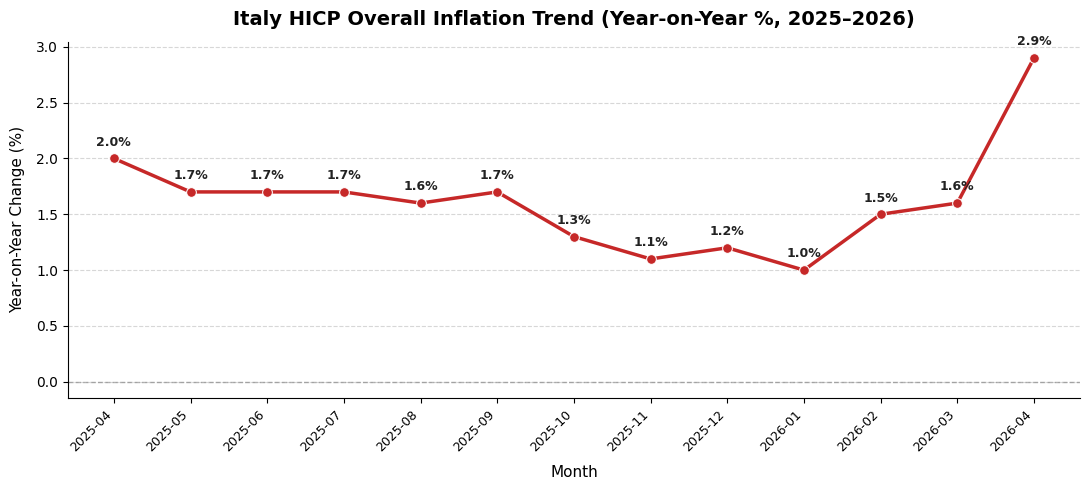

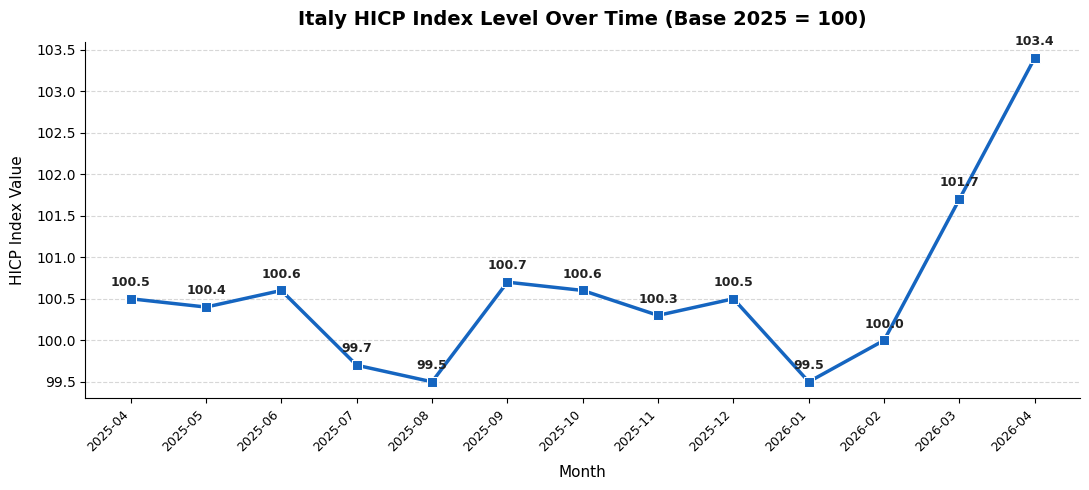

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\931432460.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=top_increases_plot, y='Label', x='Pct_Change',


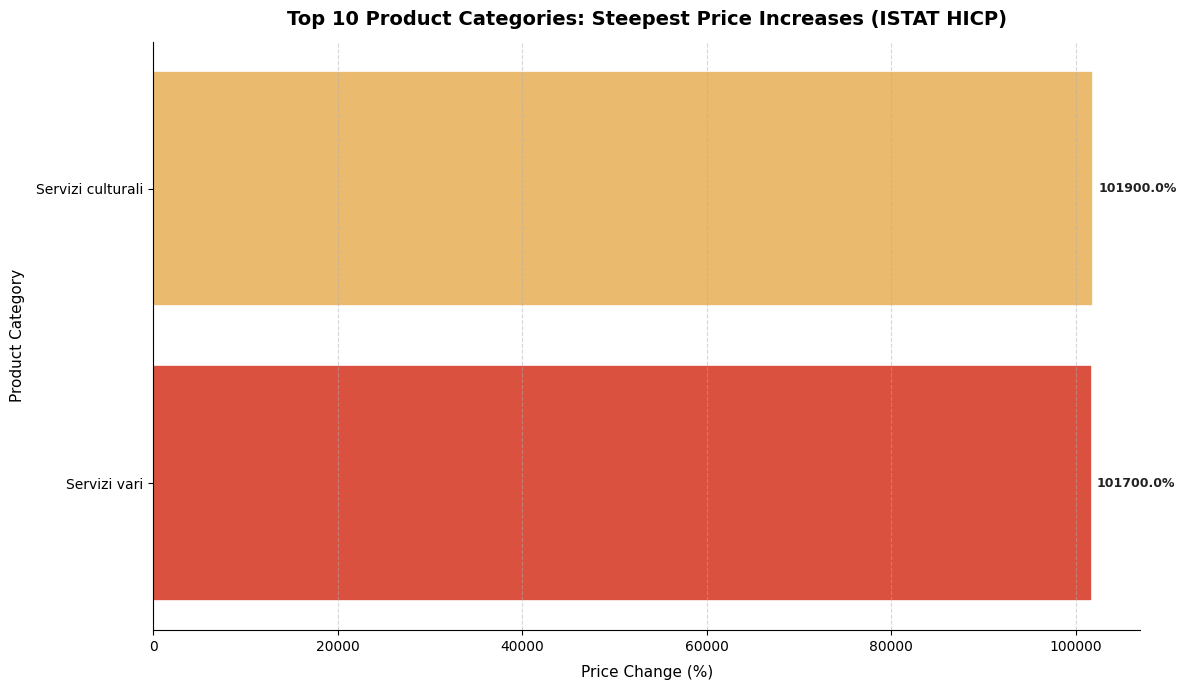

In [5]:
# ================= ISTAT HICP / NIC dataset (istat_inflation) =================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_hicp = pd.read_csv("03_istat_inflation/istat_hicp_monthly_4digit.csv", dtype=str, on_bad_lines='skip')
df_nic  = pd.read_csv("03_istat_inflation/istat_nic_weights_6digit.csv",   dtype=str, on_bad_lines='skip')

data_information_hicp = df_hicp.dtypes
data_information_nic  = df_nic.dtypes

print("\n"+'='*70)
print("\n"+'1. Data Exploration')
print("\n"+'='*70)

print("\n"+"="*70)

print("\n"+"_"*10+'Exploring HICP_dataset'+'_'*10)
print(data_information_hicp)
print("\n"+"_"*10+'Exploring NIC_dataset'+'_'*10)
print(data_information_nic)
df_hicp.info()
df_nic.info()

print("\n"+"="*70)

# =========================================================================
# Columns: ECOICOP_2 (code), ECOICOP 2 (label), TIME_PERIOD (YYYY-MM),
#          Observation (str, '..'=missing), MEASURE (4=index, 6=mom%, 7=yoy%)
# =========================================================================

# ________________________________________________________________________
# Finding answers of question through analysis
# ________________________________________________________________________
# Qno1. What is the overall HICP inflation trend in Italy? (available data: 2025-04 to 2026-04)
df_hicp_trend         = df_hicp[df_hicp['ECOICOP_2'] == '00'].copy()       # overall index (code 00)
df_hicp_trend         = df_hicp_trend[df_hicp_trend['MEASURE'] == '7']     # year-on-year % change
df_hicp_trend['Obs_num'] = pd.to_numeric(df_hicp_trend['Observation'], errors='coerce')
df_hicp_trend         = df_hicp_trend.dropna(subset=['Obs_num'])
df_hicp_trend         = df_hicp_trend.sort_values('TIME_PERIOD').reset_index(drop=True)

# ________________________________________________________________________
# Qno2. How do you compute inflation-adjusted price from raw sales data?
# Formula: Real Price = Nominal Price / (HICP Index / 100)
# We demonstrate using the HICP index series (MEASURE=4, code 00)
df_hicp_index         = df_hicp[df_hicp['ECOICOP_2'] == '00'].copy()
df_hicp_index         = df_hicp_index[df_hicp_index['MEASURE'] == '4']     # index number (base 2025=100)
df_hicp_index['Obs_num'] = pd.to_numeric(df_hicp_index['Observation'], errors='coerce')
df_hicp_index         = df_hicp_index.dropna(subset=['Obs_num'])
df_hicp_index         = df_hicp_index[['TIME_PERIOD', 'Obs_num']].rename(columns={'Obs_num': 'HICP_Index'})
df_hicp_index         = df_hicp_index.sort_values('TIME_PERIOD').reset_index(drop=True)

# Example: deflate a nominal price of 100 to real terms for each month
df_hicp_index['Real_Price_Example'] = (100.0 / df_hicp_index['HICP_Index']) * 100

# ________________________________________________________________________
# Qno3. Which retail product categories experienced the steepest price increases?
df_hicp_q             = df_hicp.copy()
df_hicp_q             = df_hicp_q[df_hicp_q['ECOICOP 2'] != 'ECOICOP_2']  # drop header rows
df_hicp_q['Obs_num']  = pd.to_numeric(df_hicp_q['Observation'], errors='coerce')
df_hicp_q             = df_hicp_q.dropna(subset=['Obs_num'])
df_hicp_q             = df_hicp_q.sort_values('TIME_PERIOD')
first_val             = df_hicp_q.groupby('ECOICOP 2')['Obs_num'].first().reset_index()
last_val              = df_hicp_q.groupby('ECOICOP 2')['Obs_num'].last().reset_index()
price_trend           = first_val.merge(last_val, on='ECOICOP 2', suffixes=('_first', '_last'))
price_trend['Pct_Change'] = ((price_trend['Obs_num_last'] - price_trend['Obs_num_first']) / price_trend['Obs_num_first']) * 100
top_increases         = price_trend.sort_values('Pct_Change', ascending=False).head(10).reset_index(drop=True)

# _________________Code for Printing results______________________________
print("\n"+'='*70)
print("\n"+"_"*70)
print("\n"+"Q#1. What is the overall HICP inflation trend in Italy?")
print("\n"+"  (ISTAT data covers: 2025-04 to 2026-04 | MEASURE=7: year-on-year % change | Code 00 = All-items)")
print("\n", df_hicp_trend[['TIME_PERIOD', 'Obs_num']].to_string(index=False))
print("\n"+"_"*70)
print("\n"+"Q#2. How do you compute inflation-adjusted price from raw sales data?")
print("\n"+"  Formula : Real Price = Nominal Price / (HICP Index / 100)")
print("\n"+"  Example : nominal price of €100 deflated to base-2025 real terms for each month")
print("\n", df_hicp_index[['TIME_PERIOD', 'HICP_Index', 'Real_Price_Example']].to_string(index=False))
print("\n"+"_"*70)
print("\n"+"Q#3. Which retail product categories experienced the steepest price increases?")
print("\n"+" Top 10 categories by % price increase (earliest to latest period):")
print("\n", top_increases)

# _________________Conclustion section _______________________________
print("\n"+'='*70)
print("\n"+'Conslusione'+'_'*10)
print("\n"+"Answer of Question # 1")
print(f" Italy HICP year-on-year inflation peaked in this period at: {df_hicp_trend['Obs_num'].max():.1f}% (month: {df_hicp_trend.loc[df_hicp_trend['Obs_num'].idxmax(), 'TIME_PERIOD']})")
print("\n"+"Answer of Question # 2")
print(" Real price = Nominal Price / (HICP / 100). A product costing €100 when HICP=103.4 costs €96.7 in real base-2025 terms.")
print("\n"+"Answer of Question # 3")
print(f" Top category with steepest price increase:")
print(f" {top_increases.iloc[0]['ECOICOP 2']}  →  {top_increases.iloc[0]['Pct_Change']:.1f}% increase")
print("\n"+'='*70)

# ________________ Ploting all the importany data_____________________

# Chart 1 — Italy HICP Year-on-Year Inflation Trend (2025-2026)
plt.figure(figsize=(11, 5))
ax1 = sns.lineplot(data=df_hicp_trend, x='TIME_PERIOD', y='Obs_num',
                   color='#C62828', linewidth=2.5, marker='o', markersize=7)
for i, row in df_hicp_trend.iterrows():
    ax1.annotate(f"{row['Obs_num']:.1f}%",
                 (i, row['Obs_num']),
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#222222',
                 xytext=(0, 7), textcoords='offset points')
plt.xticks(range(len(df_hicp_trend)), df_hicp_trend['TIME_PERIOD'], rotation=45, ha='right', fontsize=9)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.title('Italy HICP Overall Inflation Trend (Year-on-Year %, 2025–2026)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Month',                   fontsize=11, labelpad=8)
plt.ylabel('Year-on-Year Change (%)', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 2 — HICP Index Level Over Time (base 2025=100)
plt.figure(figsize=(11, 5))
ax2 = sns.lineplot(data=df_hicp_index, x='TIME_PERIOD', y='HICP_Index',
                   color='#1565C0', linewidth=2.5, marker='s', markersize=7)
for i, row in df_hicp_index.iterrows():
    ax2.annotate(f"{row['HICP_Index']:.1f}",
                 (i, row['HICP_Index']),
                 ha='center', va='bottom', fontsize=9, fontweight='bold', color='#222222',
                 xytext=(0, 7), textcoords='offset points')
plt.xticks(range(len(df_hicp_index)), df_hicp_index['TIME_PERIOD'], rotation=45, ha='right', fontsize=9)
plt.title('Italy HICP Index Level Over Time (Base 2025 = 100)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Month',            fontsize=11, labelpad=8)
plt.ylabel('HICP Index Value', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 3 — Top 10 Product Categories: Steepest Price Increases
top_increases_plot          = top_increases[top_increases['Pct_Change'] != float('inf')].copy()
top_increases_plot['Label'] = top_increases_plot['ECOICOP 2'].str[:45]     # truncate long labels
plt.figure(figsize=(12, 7))
ax3 = sns.barplot(data=top_increases_plot, y='Label', x='Pct_Change',
                  palette='YlOrRd', edgecolor='white', linewidth=1.2)
for p in ax3.patches:
    ax3.annotate(f'{p.get_width():.1f}%',
                 (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=9, fontweight='bold', color='#222222',
                 xytext=(4, 0), textcoords='offset points')
plt.title('Top 10 Product Categories: Steepest Price Increases (ISTAT HICP)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Price Change (%)',  fontsize=11, labelpad=8)
plt.ylabel('Product Category', fontsize=11, labelpad=8)
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\akbar\AppData\Local\Temp\ipykernel_17572\2251622488.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=italy_inf, x='TIME_PERIOD', y='OBS_VALUE',




1. Data Exploration


__________Exploring eurostat_hicp_annual_index__________
DATAFLOW           str
LAST UPDATE        str
freq               str
unit               str
coicop             str
geo                str
TIME_PERIOD      int64
OBS_VALUE      float64
OBS_FLAG           str
CONF_STATUS    float64
dtype: object

__________Exploring eurostat_hicp_inflation_rate__________
DATAFLOW           str
LAST UPDATE        str
freq               str
unit               str
coicop18           str
geo                str
TIME_PERIOD      int64
OBS_VALUE      float64
OBS_FLAG       float64
CONF_STATUS    float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 8556 entries, 0 to 8555
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATAFLOW     8556 non-null   str    
 1   LAST UPDATE  8556 non-null   str    
 2   freq         8556 non-null   str    
 3   unit         8556 non-null   str    
 4   coicop       8556 

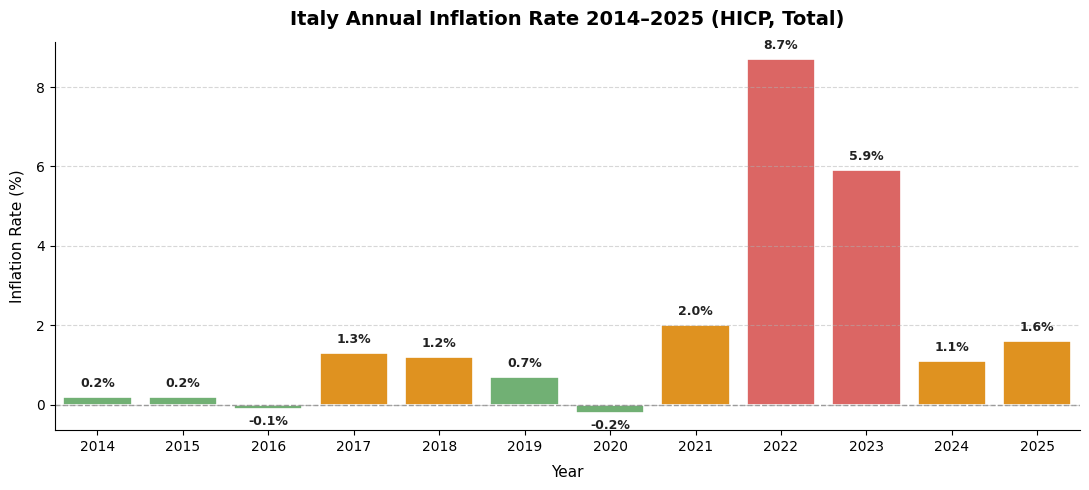

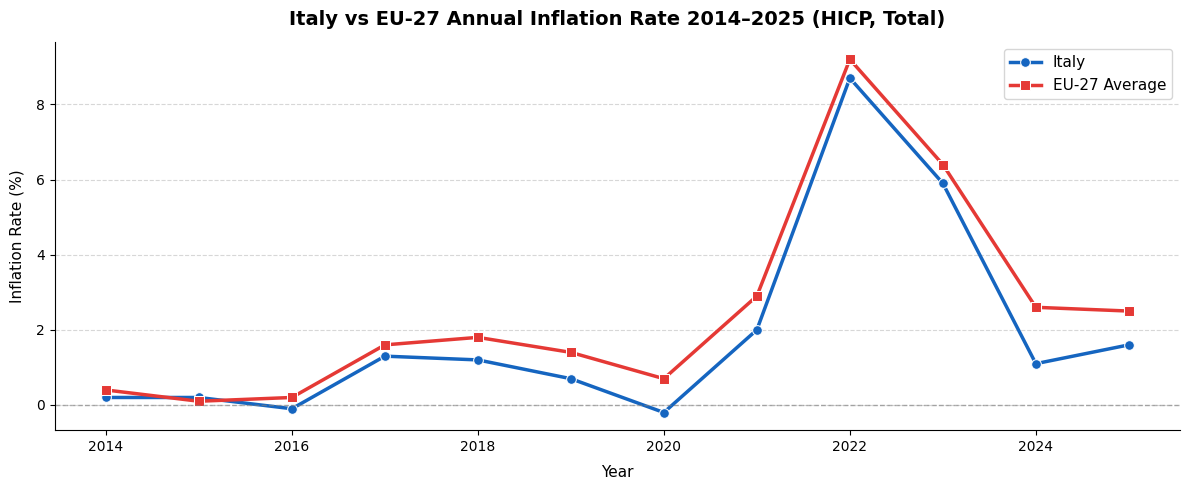

In [6]:
# ================= Eurostat HICP dataset (eurostat_cpi) =================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hicp_annual   = pd.read_csv("04_eurostat_cpi/eurostat_hicp_annual_index.csv")
hicp_inf_rate = pd.read_csv("04_eurostat_cpi/eurostat_hicp_inflation_rate.csv")

df_annual   = pd.DataFrame(hicp_annual)
df_inf_rate = pd.DataFrame(hicp_inf_rate)

data_information_annual   = df_annual.dtypes
data_information_inf_rate = df_inf_rate.dtypes

print("\n"+'='*70)
print("\n"+'1. Data Exploration')
print("\n"+'='*70)

print("\n"+"_"*10+'Exploring eurostat_hicp_annual_index'+'_'*10)
print(data_information_annual)
print("\n"+"_"*10+'Exploring eurostat_hicp_inflation_rate'+'_'*10)
print(data_information_inf_rate)
df_annual.info()
df_inf_rate.info()
df_annual.describe()
df_inf_rate.describe()

print("\n"+"="*70)

# =========================================================================
# df_annual   : geo='Italy', coicop='All-items HICP', TIME_PERIOD 2010-2025
# df_inf_rate : geo='Italy' / 'European Union - 27 countries (from 2020)'
#               coicop18='Total', TIME_PERIOD 2014-2025
# =========================================================================

# ________________________________________________________________________
# Finding answers of question through analysis
# ________________________________________________________________________
# Qno1. What was Italy's annual inflation rate year by year from 2014 to 2025?
italy_inf             = df_inf_rate[(df_inf_rate['geo'] == 'Italy') &
                                    (df_inf_rate['coicop18'] == 'Total')].copy()
italy_inf             = italy_inf.sort_values('TIME_PERIOD').reset_index(drop=True)

# ________________________________________________________________________
# Qno2. How does Italy's inflation compare to the EU average?
eu_label              = 'European Union - 27 countries (from 2020)'
italy_eu_inf          = df_inf_rate[(df_inf_rate['coicop18'] == 'Total') &
                                    (df_inf_rate['geo'].isin(['Italy', eu_label]))].copy()
italy_eu_inf          = italy_eu_inf.sort_values(['geo', 'TIME_PERIOD']).reset_index(drop=True)
italy_eu_inf['geo_label'] = italy_eu_inf['geo'].map({'Italy': 'Italy', eu_label: 'EU-27 Average'})

# _________________Code for Printing results______________________________
print("\n"+'='*70)
print("\n"+"_"*70)
print("\n"+"Q#1. What was Italy's annual inflation rate year by year from 2014 to 2025?")
print("\n", italy_inf[['TIME_PERIOD', 'OBS_VALUE']].to_string(index=False))
print("\n"+"_"*70)
print("\n"+"Q#2. How does Italy's inflation compare to the EU average?")
print("\n", italy_eu_inf[['geo_label', 'TIME_PERIOD', 'OBS_VALUE']].to_string(index=False))

# _________________Conclustion section _______________________________
print("\n"+'='*70)
print("\n"+'Conslusione'+'_'*10)
print("\n"+"Answer of Question # 1")
peak_year  = italy_inf.loc[italy_inf['OBS_VALUE'].idxmax(), 'TIME_PERIOD']
peak_val   = italy_inf['OBS_VALUE'].max()
print(f" Italy's inflation peaked in {peak_year} at {peak_val:.1f}%, driven by the post-COVID energy crisis.")
low_year   = italy_inf.loc[italy_inf['OBS_VALUE'].idxmin(), 'TIME_PERIOD']
low_val    = italy_inf['OBS_VALUE'].min()
print(f" The lowest rate was in {low_year} at {low_val:.1f}%, reflecting deflation or weak demand.")
print("\n"+"Answer of Question # 2")
it_avg     = italy_eu_inf[italy_eu_inf['geo_label'] == 'Italy']['OBS_VALUE'].mean()
eu_avg     = italy_eu_inf[italy_eu_inf['geo_label'] == 'EU-27 Average']['OBS_VALUE'].mean()
print(f" Over 2014-2025, Italy's average inflation ({it_avg:.2f}%) was {'below' if it_avg < eu_avg else 'above'} the EU-27 average ({eu_avg:.2f}%).")
print("\n"+'='*70)

# ________________ Ploting all the importany data_____________________

# Chart 1 — Italy Annual Inflation Rate 2014-2025
colors_bar = ['#EF5350' if v > 3 else '#FF9800' if v > 1 else '#66BB6A' for v in italy_inf['OBS_VALUE']]
plt.figure(figsize=(11, 5))
ax1 = sns.barplot(data=italy_inf, x='TIME_PERIOD', y='OBS_VALUE',
                  palette=colors_bar, edgecolor='white', linewidth=1.2)
for p in ax1.patches:
    val = p.get_height()
    ax1.annotate(f'{val:.1f}%',
                 (p.get_x() + p.get_width() / 2., val),
                 ha='center', va='bottom' if val >= 0 else 'top',
                 fontsize=9, fontweight='bold', color='#222222',
                 xytext=(0, 5 if val >= 0 else -5), textcoords='offset points')
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.title("Italy Annual Inflation Rate 2014–2025 (HICP, Total)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Year',               fontsize=11, labelpad=8)
plt.ylabel('Inflation Rate (%)', fontsize=11, labelpad=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Chart 2 — Italy vs EU-27 Inflation Comparison 2014-2025
it_data = italy_eu_inf[italy_eu_inf['geo_label'] == 'Italy'].reset_index(drop=True)
eu_data = italy_eu_inf[italy_eu_inf['geo_label'] == 'EU-27 Average'].reset_index(drop=True)
plt.figure(figsize=(12, 5))
ax2 = sns.lineplot(data=it_data, x='TIME_PERIOD', y='OBS_VALUE',
                   color='#1565C0', linewidth=2.5, marker='o', markersize=7, label='Italy')
sns.lineplot(data=eu_data, x='TIME_PERIOD', y='OBS_VALUE',
             color='#E53935', linewidth=2.5, marker='s', markersize=7, label='EU-27 Average', ax=ax2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.title("Italy vs EU-27 Annual Inflation Rate 2014–2025 (HICP, Total)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Year',               fontsize=11, labelpad=8)
plt.ylabel('Inflation Rate (%)', fontsize=11, labelpad=8)
plt.legend(fontsize=11, framealpha=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

In [7]:
# ================= Saving Rossmann data to SQLite =================
import sqlite3
import pandas as pd

conn_rossmann = sqlite3.connect('kaggle_rossmann.db')
df_train.to_sql('rossmann_train', conn_rossmann, if_exists='replace', index=False)
df_test.to_sql('rossmann_test',   conn_rossmann, if_exists='replace', index=False)
conn_rossmann.close()
print("Rossmann data saved to kaggle_rossmann.db")

DatabaseError: Execution failed

In [ ]:
# ================= Saving Demand Forecasting data to SQLite =================
import sqlite3
import pandas as pd

conn_demand = sqlite3.connect('kaggle_demand_forecasting.db')
df_sales.to_sql('retail_sales',    conn_demand, if_exists='replace', index=False)
df_sale_train.to_sql('store_item_demand', conn_demand, if_exists='replace', index=False)
conn_demand.close()
print("Demand forecasting data saved to kaggle_demand_forecasting.db")

In [ ]:
# ================= Saving ISTAT data to SQLite =================
import sqlite3
import pandas as pd

conn_istat = sqlite3.connect('istat_inflation.db')
df_hicp.to_sql('istat_hicp_monthly', conn_istat, if_exists='replace', index=False)
df_nic.to_sql('istat_nic_weights',   conn_istat, if_exists='replace', index=False)
conn_istat.close()
print("ISTAT data saved to istat_inflation.db")

In [ ]:
# ================= Saving Eurostat data to SQLite =================
import sqlite3
import pandas as pd

conn_eurostat = sqlite3.connect('eurostat_cpi.db')
df_annual.to_sql('eurostat_hicp_annual',   conn_eurostat, if_exists='replace', index=False)
df_inf_rate.to_sql('eurostat_inf_rate',    conn_eurostat, if_exists='replace', index=False)
conn_eurostat.close()
print("Eurostat data saved to eurostat_cpi.db")